In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#0-importation des paramètres configs.py et installation des librairies (à définir)
import config
import os

if os.path.exists("requirements.txt"):
    print("Installation des dépendances en cours...")
    %pip install -r requirements.txt --quiet
    print("Dépendances installées avec succès !")

Installation des dépendances en cours...


Note: you may need to restart the kernel to use updated packages.
Dépendances installées avec succès !


In [ ]:
# ATTENTION : à faire uniquement si problème pour utiliser la gpu sur onyxia
%pip install torch torchvision torchaudio --force-reinstall --index-url https://download.pytorch.org/whl/cu124
!sudo apt-get update && sudo apt-get install -y libgl1

In [ ]:
#importation des donnees depuis S3 (si existent)
import src.importation_donnees_s3 

#importation des données DDSM depuis S3 vers le local
src.importation_donnees_s3.sync_s3_to_local(config.BUCKET_S3_DDSM, config.DDSM_PATH_LOCAL) 

#importation des données Vindr depuis S3 vers le local
os.makedirs(config.CHEMIN_DATA_VINDR, exist_ok=True)
src.importation_donnees_s3.sync_s3_to_local(config.BUCKET_S3_VINDR_NORMAL, config.VINDR_PATH_LOCAL_NORMAL) 
src.importation_donnees_s3.sync_s3_to_local(config.BUCKET_S3_VINDR_CANCER_BENIGN, config.VINDR_PATH_LOCAL_CANCER_BENIGN) 



In [ ]:
#1-importation_des_donnees_et_structuration (si donnees deja importes, passer cette etape)

In [4]:
#2-generation donnees miniddsm
from src.entrainement_ddsm import entrainement_model
from src.entrainement_ddsm import generation_donnees
import torch
from torchvision.models import ResNet18_Weights
import torchvision.models as models
import torch.nn as nn
import gc

# Generation des données
train_loader_DDSM, val_loader_DDSM, test_loader_DDSM = generation_donnees(
    chemin_data=config.DDSM_PATH_LOCAL,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=config.CHOIX_FONCTION,
    brightness=config.BRIGHTNESS,
    contrast=config.CONTRAST,
    degrees=config.DEGREES,
    test_size=config.TEST_SIZE,
    val_size=config.VAL_SIZE,
    train_size=config.TRAIN_SIZE,
    numero_random=config.NUMERO_RANDOM,
    normalize=config.NORMALIZE
)

# Vérification GPU
print(f"GPU disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU détecté : {torch.cuda.get_device_name(0)}")
else:
    print("Pas de GPU, utilisation du CPU")

# Création du modèle et configuration GPU
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Sequential(
    nn.Dropout(p=config.DROPOUT),  # Désactive 50% des neurones aléatoirement à chaque itération
    nn.Linear(model.fc.in_features, 1))

# Configuration GPU
device = torch.device("cuda:0")
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config.LR, weight_decay=config.WEIGHT_DECAY)  # ajout d'un weightdecay pour pénaliser l'overfitting
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=config.FACTOR, patience=config.PATIENCE, threshold=config.THRESHOLD)



Nombre total d'images : 2922
Classes détectées : ['0-normal', '1-cancer_benign']
Distribution des classes : Counter({np.int64(0): 1873, np.int64(1): 1049})
accuracy random val : 0.6409993155373033
Train set: 2044
Validation set: 439
Test set: 439
Distribution dans train : Counter({np.int64(0): 1311, np.int64(1): 733})
Poids par classe : {np.int64(0): 1.559115179252479, np.int64(1): 2.7885402455661663}
GPU disponible : True
GPU détecté : Tesla T4


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/onyxia/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  5%|▌         | 2.38M/44.7M [00:00<00:01, 23.4MB/s]

 10%|█         | 4.62M/44.7M [00:00<00:01, 21.5MB/s]

 15%|█▌        | 6.75M/44.7M [00:00<00:02, 19.4MB/s]

 35%|███▌      | 15.8M/44.7M [00:00<00:00, 45.7MB/s]

 58%|█████▊    | 26.1M/44.7M [00:00<00:00, 66.7MB/s]

 83%|████████▎ | 37.1M/44.7M [00:00<00:00, 82.2MB/s]

100%|██████████| 44.7M/44.7M [00:00<00:00, 64.7MB/s]

In [7]:
!mkdir -p /home/onyxia/work/ot-domain-adaptation-mammography/projet/model

In [ ]:
#entraînement du modèle
entrainement_model(
    model=model,
    train_loader=train_loader_DDSM,  
    val_loader=val_loader_DDSM,      
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    num_epochs=config.NUM_EPOCHS,
    patience=config.PATIENCE,
    patience_limite=config.PATIENCE_LIMITE,
    device=device,
    nom_modele_sauvegarde=config.NOM_MODELE_SAUVEGARDE,
    chemin_modele_local=config.CHEMIN_MODELE_LOCAL,
    chemin_modele_s3=config.CHEMIN_MODELE_S3,
    base_dir = config.BASE_DIR
)

#nettoyage de la VRAM
gc.collect()
torch.cuda.empty_cache()

In [ ]:
#3-evaluation_modele_sur_mini_ddsm
from src.evaluation import evaluation

#récupération du modèle
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5), # Désactive 50% des neurones aléatoirement à chaque itération
    nn.Linear(model.fc.in_features, 1))

model.load_state_dict(torch.load(config.CHEMIN_MODELE_LOCAL))

device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

#evaluation du modèle sur le dataset test
labels_np0, predictions_np0, probabilities_np0 = evaluation(model, test_loader_DDSM, device)

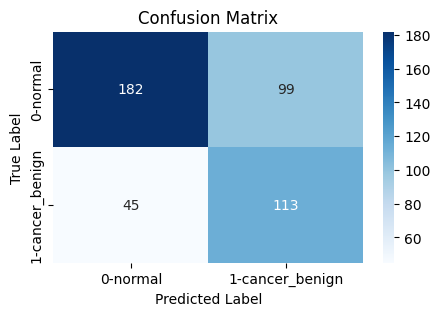

In [7]:
#matrice de confusion
from src.evaluation import matrice_confusion

matrice_confusion(labels_np0, predictions_np0, class_names=["0-normal", "1-cancer_benign"])

In [8]:
#rapport de classification
from src.evaluation import rapport_classification

rapport_classification(labels_np0, predictions_np0, class_names=["0-normal", "1-cancer_benign"])


RAPPORT DE CLASSIFICATION
                 precision    recall  f1-score   support

       0-normal       0.80      0.65      0.72       281
1-cancer_benign       0.53      0.72      0.61       158

       accuracy                           0.67       439
      macro avg       0.67      0.68      0.66       439
   weighted avg       0.71      0.67      0.68       439



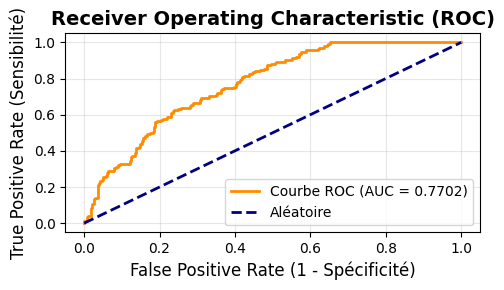

AUC = 0.7702 [IC 95% : 0.7273 - 0.8090]


In [9]:
#courbe roc et auc
from src.evaluation import courbe_roc_auc

courbe_roc_auc(labels_np0, probabilities_np0, n_bootstrap=1000, alpha=0.05)

In [ ]:
#4-evaluation_modele_sur_vindr
from src.entrainement_ddsm import generation_donnees

#on récupère et on transforme les données
_, _, test_loader_VINDR = generation_donnees(
    chemin_data=config.CHEMIN_DATA_VINDR,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=config.CHOIX_FONCTION,
    brightness=0,
    contrast=0,
    degrees=0,
    test_size=1.0,
    val_size=0,
    train_size=0,
    numero_random=config.NUMERO_RANDOM,
    normalize=config.NORMALIZE
)

#3-evaluation_modele_sur_Vindr
labels_np1, predictions_np1, probabilities_np1 = evaluation(model, test_loader_VINDR, device)

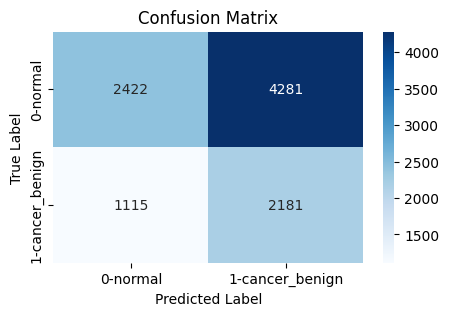

In [11]:
#matrice de confusion
from src.evaluation import matrice_confusion

matrice_confusion(labels_np1, predictions_np1, class_names=["0-normal", "1-cancer_benign"])

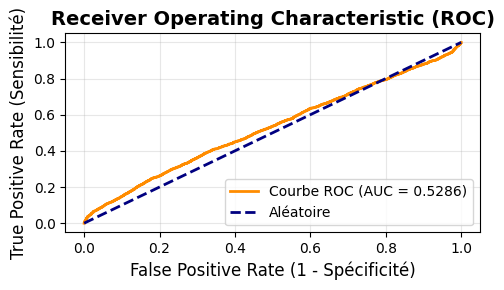

AUC = 0.5286 [IC 95% : 0.5168 - 0.5412]


In [12]:
#courbe roc et auc
from src.evaluation import courbe_roc_auc

courbe_roc_auc(labels_np1, probabilities_np1, n_bootstrap=1000, alpha=0.05)

In [13]:
#Visualisation distribution
from src.domain_transport import distribution_pixels

#recuperation des distributions brutes
_, _, test_loader_VINDR_brut = generation_donnees(
    chemin_data=config.CHEMIN_DATA_VINDR,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=config.CHOIX_FONCTION,
    brightness=0,
    contrast=0,
    degrees=0,
    test_size=1.0,
    val_size=0,
    train_size=0,
    numero_random=config.NUMERO_RANDOM,
    normalize=0
)

_, _, test_loader_DDSM_brut = generation_donnees(
    chemin_data=config.DDSM_PATH_LOCAL,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=config.CHOIX_FONCTION,
    brightness=0,
    contrast=0,
    degrees=0,
    test_size=1.0,
    val_size=0,
    train_size=0,
    numero_random=config.NUMERO_RANDOM,
    normalize=0
)

#recuperation des pixels des datasets sources et cibles
(source_pixels, target_pixels) =  distribution_pixels(test_loader_DDSM_brut, test_loader_VINDR_brut, n_batches=10)



Nombre total d'images : 9999
Classes détectées : ['0-normal', '1-cancer_benign']
Distribution des classes : Counter({np.int64(0): 6703, np.int64(1): 3296})
accuracy random val : 0.6703670367036704

---> Mode Inférence activé : 100% des données assignées au Test Set.
Nombre total d'images : 2922
Classes détectées : ['0-normal', '1-cancer_benign']
Distribution des classes : Counter({np.int64(0): 1873, np.int64(1): 1049})
accuracy random val : 0.6409993155373033

---> Mode Inférence activé : 100% des données assignées au Test Set.


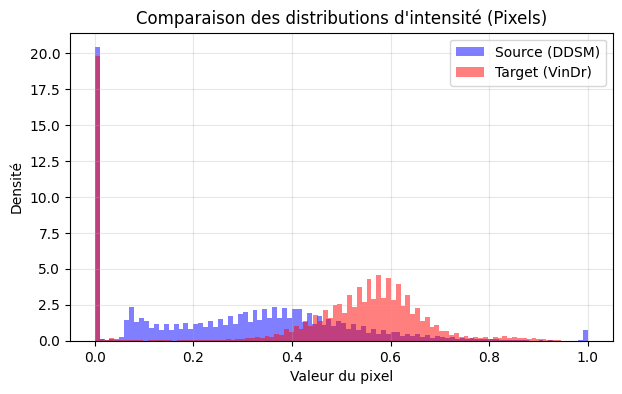

()

In [14]:
#representation de la distribution des pixels
from src.domain_transport import plot_distributions
plot_distributions(source_pixels, target_pixels)

In [15]:
# recentrage sur moyenne et ecart type cible windsorisées
from src.domain_transport import robust_mean_variance

#calcul des moyennes et écarts-types
mu_ddsm, sigma_ddsm = robust_mean_variance(source_pixels)
mu_vindr, sigma_vindr = robust_mean_variance(target_pixels)



Nombre total d'images : 9999
Classes détectées : ['0-normal', '1-cancer_benign']
Distribution des classes : Counter({np.int64(0): 6703, np.int64(1): 3296})
accuracy random val : 0.6703670367036704

---> Mode Inférence activé : 100% des données assignées au Test Set.


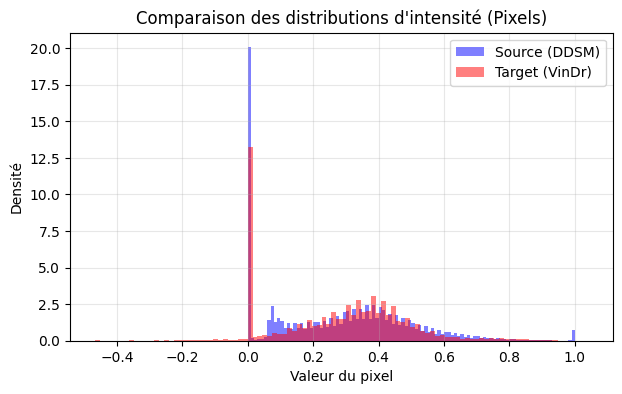

()

In [16]:
#visualisation nouvel histogramme
from src.entrainement_ddsm import generation_donnees

#generation des données recentrées brut
_, _, test_loader_VINDR_normalise_brut = generation_donnees(
    chemin_data=config.CHEMIN_DATA_VINDR,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=2,
    brightness=0,
    contrast=0,
    degrees=0,
    test_size=1.0,
    val_size=0,
    train_size=0,
    numero_random=config.NUMERO_RANDOM,
    normalize=0,
    mu_ddsm=mu_ddsm,
    sigma_ddsm=sigma_ddsm,
    mu_vindr=mu_vindr,
    sigma_vindr=sigma_vindr
)

# visualisation histrogramme 
(source_pixels, target_pixels2) =  distribution_pixels(test_loader_DDSM_brut, test_loader_VINDR_normalise_brut, n_batches=10)

plot_distributions(source_pixels, target_pixels2)


In [ ]:
#evaluation du modèle
#generation des données recentrées brute
_, _, test_loader_VINDR_normalise = generation_donnees(
    chemin_data=config.CHEMIN_DATA_VINDR,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=2,
    brightness=0,
    contrast=0,
    degrees=0,
    test_size=1.0,
    val_size=0,
    train_size=0,
    numero_random=config.NUMERO_RANDOM,
    normalize=1,
    mu_ddsm=mu_ddsm,
    sigma_ddsm=sigma_ddsm,
    mu_vindr=mu_vindr,
    sigma_vindr=sigma_vindr
)
labels_np2, predictions_np2, probabilities_np2 = evaluation(model, test_loader_VINDR_normalise, device)


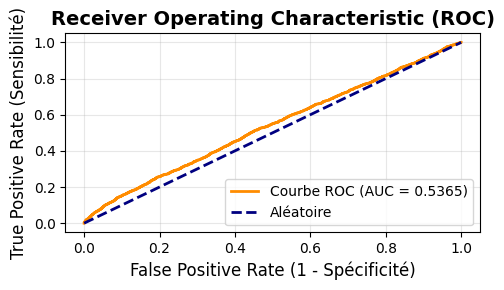

AUC = 0.5365 [IC 95% : 0.5246 - 0.5485]


In [18]:
#courbe ROC - AUC
from src.evaluation import courbe_roc_auc
courbe_roc_auc(labels_np2, probabilities_np2, n_bootstrap=1000, alpha=0.05)

Calcul des quantiles Source...


Calcul des quantiles Target...


Nombre total d'images : 9999
Classes détectées : ['0-normal', '1-cancer_benign']
Distribution des classes : Counter({np.int64(0): 6703, np.int64(1): 3296})
accuracy random val : 0.6703670367036704

---> Mode Inférence activé : 100% des données assignées au Test Set.


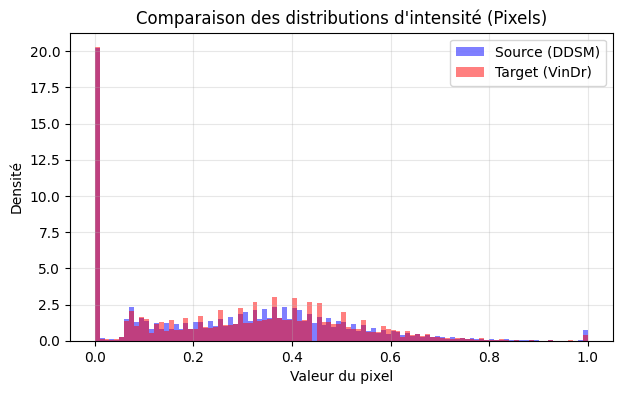

()

In [19]:
#5-visualisation_modele_sur_vindr_avec_transport_de_domaine (à la main et avec le modèle)
from src.domain_transport import calcul_quantile
from src.domain_transport import plot_distributions
from src.entrainement_ddsm import entrainement_model
from src.entrainement_ddsm import generation_donnees
import torch
from torchvision.models import ResNet18_Weights
import torchvision.models as models
import torch.nn as nn
import gc
(value_quantile_source, value_quantile_target) = calcul_quantile(test_loader_DDSM_brut, test_loader_VINDR_brut, n_batches=10)

#evaluation du modèle
#generation des données recentrées brute
_, _, test_loader_VINDR_OT_transport_brut = generation_donnees(
    chemin_data=config.CHEMIN_DATA_VINDR,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=3,
    brightness=0,
    contrast=0,
    degrees=0,
    test_size=1.0,
    val_size=0,
    train_size=0,
    numero_random=config.NUMERO_RANDOM,
    normalize=0,
    value_quantile_target=value_quantile_target, 
    value_quantile_source=value_quantile_source
)

# visualisation histrogramme 
(source_pixels, target_pixels3) =  distribution_pixels(test_loader_DDSM_brut, test_loader_VINDR_OT_transport_brut, n_batches=10)

plot_distributions(source_pixels, target_pixels3)


In [ ]:
#evaluation du modèle
#generation des données recentrées brute
_, _, test_loader_VINDR_ot_transport = generation_donnees(
    chemin_data=config.CHEMIN_DATA_VINDR,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=3,
    brightness=0,
    contrast=0,
    degrees=0,
    test_size=1.0,
    val_size=0,
    train_size=0,
    numero_random=config.NUMERO_RANDOM,
    normalize=1,
    value_quantile_target=value_quantile_target, 
    value_quantile_source=value_quantile_source
)

labels_np3, predictions_np3, probabilities_np3 = evaluation(model, test_loader_VINDR_ot_transport, device)


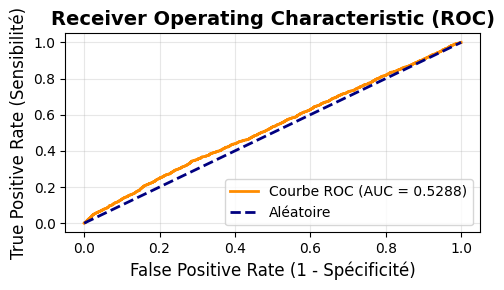

AUC = 0.5288 [IC 95% : 0.5176 - 0.5408]


In [22]:
from src.evaluation import courbe_roc_auc
courbe_roc_auc(labels_np3, probabilities_np3, n_bootstrap=1000, alpha=0.05)

In [3]:
#avec CLAHE (la logique est un peu différente, il faut non pas adapter vindr à miniddsm mais "uniformiser" à la fois ddsm et vindr)
#attention à ne pas toucher au contrataste car clahe y touche déjà d'une certaine manière
#2-generation donnees miniddsm
from src.entrainement_ddsm import entrainement_model
from src.entrainement_ddsm import generation_donnees
import torch
from torchvision.models import ResNet18_Weights
import torchvision.models as models
import torch.nn as nn
import gc

# Generation des données
train_loader_DDSM_clahe, val_loader_DDSM_clahe, test_loader_DDSM_clahe = generation_donnees(
    chemin_data=config.DDSM_PATH_LOCAL,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=4,
    brightness=config.BRIGHTNESS,
    contrast=0,
    degrees=config.DEGREES,
    test_size=config.TEST_SIZE,
    val_size=config.VAL_SIZE,
    train_size=config.TRAIN_SIZE,
    numero_random=config.NUMERO_RANDOM,
    normalize=1
)

# Vérification GPU
print(f"GPU disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU détecté : {torch.cuda.get_device_name(0)}")
else:
    print("Pas de GPU, utilisation du CPU")

# Création du modèle et configuration GPU
model_clahe = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model_clahe.fc = nn.Sequential(
    nn.Dropout(p=config.DROPOUT),  # Désactive 50% des neurones aléatoirement à chaque itération
    nn.Linear(model_clahe.fc.in_features, 1))

# Configuration GPU
device_clahe = torch.device("cuda:0")
model_clahe = model_clahe.to(device_clahe)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_clahe.parameters(), lr=config.LR, weight_decay=config.WEIGHT_DECAY)  # ajout d'un weightdecay pour pénaliser l'overfitting
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=config.FACTOR, patience=config.PATIENCE, threshold=config.THRESHOLD)




Nombre total d'images : 2922
Classes détectées : ['0-normal', '1-cancer_benign']
Distribution des classes : Counter({np.int64(0): 1873, np.int64(1): 1049})
accuracy random val : 0.6409993155373033
Train set: 2044
Validation set: 439
Test set: 439
Distribution dans train : Counter({np.int64(0): 1311, np.int64(1): 733})
Poids par classe : {np.int64(0): 1.559115179252479, np.int64(1): 2.7885402455661663}
GPU disponible : True
GPU détecté : Tesla T4


In [ ]:
#entraînement du modèle
entrainement_model(
    model=model_clahe,
    train_loader=train_loader_DDSM_clahe,  
    val_loader=val_loader_DDSM_clahe,      
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    num_epochs=config.NUM_EPOCHS,
    patience=config.PATIENCE,
    patience_limite=config.PATIENCE_LIMITE,
    device=device_clahe,
    nom_modele_sauvegarde=config.NOM_MODELE_SAUVEGARDE_CLAHE,
    chemin_modele_local=config.CHEMIN_MODELE_LOCAL_CLAHE,
    chemin_modele_s3=config.CHEMIN_MODELE_S3_CLAHE,
    base_dir = config.BASE_DIR
)

#nettoyage de la VRAM
gc.collect()
torch.cuda.empty_cache()

In [ ]:
#evaluation avec clahe
from src.evaluation import evaluation

#récupération du modèle
model_clahe = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model_clahe.fc = nn.Sequential(
    nn.Dropout(p=0.5), # Désactive 50% des neurones aléatoirement à chaque itération
    nn.Linear(model_clahe.fc.in_features, 1))

model_clahe.load_state_dict(torch.load(config.CHEMIN_MODELE_LOCAL_CLAHE))

device_clahe=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_clahe.to(device_clahe)

_, _, test_loader_VINDR_ot_transport_clahe = generation_donnees(
    chemin_data=config.CHEMIN_DATA_VINDR,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=4,
    brightness=0,
    contrast=0,
    degrees=0,
    test_size=1.0,
    val_size=0,
    train_size=0,
    numero_random=config.NUMERO_RANDOM,
    normalize=1,
)

labels_np4, predictions_np4, probabilities_np4 = evaluation(model_clahe, test_loader_VINDR_ot_transport_clahe, device_clahe)


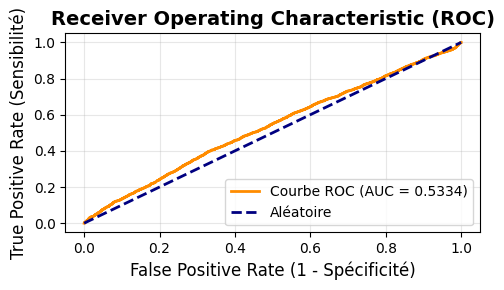

AUC = 0.5334 [IC 95% : 0.5213 - 0.5461]


In [6]:
from src.evaluation import courbe_roc_auc
courbe_roc_auc(labels_np4, probabilities_np4, n_bootstrap=1000, alpha=0.05)

In [ ]:
#5-visualisation_modele_sur_vindr_avec_transport_de_domaine (à la main et avec le modèle)
from src.domain_transport import distribution_pixels
from src.domain_transport import calcul_quantile
from src.domain_transport import plot_distributions
from src.entrainement_ddsm import entrainement_model
from src.entrainement_ddsm import generation_donnees
import torch
from torchvision.models import ResNet18_Weights
import torchvision.models as models
import torch.nn as nn
import gc

#evaluation du modèle
#generation des données recentrées brute
_, _, test_loader_VINDR_OT_transport_clahe_brut = generation_donnees(
    chemin_data=config.CHEMIN_DATA_VINDR,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=4,
    brightness=0,
    contrast=0,
    degrees=0,
    test_size=1.0,
    val_size=0,
    train_size=0,
    numero_random=config.NUMERO_RANDOM,
    normalize=0,

)

_, _, test_loader_DDSM_OT_transport_clahe_brut = generation_donnees(
    chemin_data=config.DDSM_PATH_LOCAL,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=4,
    brightness=0,
    contrast=0,
    degrees=0,
    test_size=1.0,
    val_size=0,
    train_size=0,
    numero_random=config.NUMERO_RANDOM,
    normalize=0,

)

# visualisation histrogramme 
(source_pixels, target_pixels4) =  distribution_pixels(test_loader_DDSM_OT_transport_clahe_brut, test_loader_VINDR_OT_transport_clahe_brut, n_batches=10)

plot_distributions(source_pixels, target_pixels4)


In [6]:
#6-reentrainement_modele_avec_EWC
from src.EWC import compute_fisher
from src.EWC import poids_optimaux
import torch.optim as optim

#récupération du modèle
model_ewc = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model_ewc.fc = nn.Sequential(
    nn.Dropout(p=0), # Désactive 0% des neurones aléatoirement à chaque itération
    nn.Linear(model_ewc.fc.in_features, 1))
model_ewc.load_state_dict(torch.load(config.CHEMIN_MODELE_LOCAL))
device_ewc=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_ewc.to(device_ewc)
optimizer_ewc = optim.Adam(model_ewc.parameters(), lr=config.LR, weight_decay=config.WEIGHT_DECAY)
scheduler_ewc = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ewc, mode='min', factor=config.FACTOR, patience=config.PATIENCE)

fischer_diagonal = compute_fisher(model_ewc, test_loader_DDSM, device_ewc)
dictionnaire_poids_optimaux = poids_optimaux(model_ewc)


In [ ]:
#renetrainement EWC
from src.entrainement_ddsm import generation_donnees
from src.entrainement_ddsm import entrainement_model

#generation des données d'entraînement Vindr 
train_loader_vindr_ewc, val_loader_vindr_ewc, test_loader_vindr_ewc = generation_donnees(
    chemin_data=config.CHEMIN_DATA_VINDR,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=0,
    brightness=0,
    contrast=0,
    degrees=0,
    test_size=config.TEST_SIZE,
    val_size=config.VAL_SIZE,
    train_size=config.TRAIN_SIZE,
    numero_random=config.NUMERO_RANDOM,
)

entrainement_model(
    model=model_ewc,
    train_loader=train_loader_vindr_ewc,  
    val_loader=val_loader_vindr_ewc,      
    optimizer=optimizer_ewc,
    criterion=criterion,
    scheduler=scheduler_ewc,
    num_epochs=3,
    patience=config.PATIENCE,
    patience_limite=config.PATIENCE_LIMITE,
    device=device_ewc,
    nom_modele_sauvegarde=config.NOM_MODELE_SAUVEGARDE_EWC,
    chemin_modele_local=config.CHEMIN_MODELE_LOCAL_EWC,
    chemin_modele_s3=config.CHEMIN_MODELE_S3_EWC,
    base_dir = config.BASE_DIR,
    EWC=True, 
    fischer=fischer_diagonal,
    opt_weights=dictionnaire_poids_optimaux,
    lam=400
    )


#nettoyage de la VRAM
gc.collect()
torch.cuda.empty_cache()

In [ ]:
#7-evluation_modele_EWC sur test DDSM
#récupération du modèle
model_ewc = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model_ewc.fc = nn.Sequential(
    nn.Dropout(p=0), # Désactive 0% des neurones aléatoirement à chaque itération
    nn.Linear(model_ewc.fc.in_features, 1))

model_ewc.load_state_dict(torch.load(config.CHEMIN_MODELE_LOCAL_EWC))

device_ewc=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_ewc.to(device_ewc)

from src.evaluation import evaluation


#evaluation du modèle sur le dataset test vindr et ddsm
labels_np5, predictions_np5, probabilities_np5 = evaluation(model_ewc, test_loader_DDSM, device_ewc)
labels_np6, predictions_np6, probabilities_np6 = evaluation(model_ewc, test_loader_vindr_ewc, device_ewc)



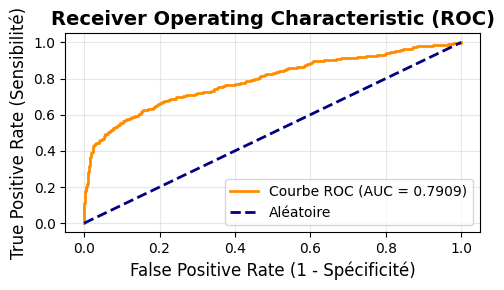

AUC = 0.7909 [IC 95% : 0.7638 - 0.8179]


In [9]:
from src.evaluation import courbe_roc_auc
courbe_roc_auc(labels_np6, probabilities_np6, n_bootstrap=1000, alpha=0.05)

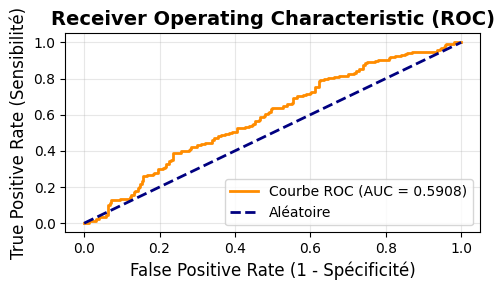

AUC = 0.5908 [IC 95% : 0.5351 - 0.6432]


In [10]:
from src.evaluation import courbe_roc_auc
courbe_roc_auc(labels_np5, probabilities_np5, n_bootstrap=1000, alpha=0.05)

In [ ]:
#pour plusieurs valeurs de lambda
from src.EWC import compute_fisher
from src.EWC import poids_optimaux
import torch.optim as optim
from src.entrainement_ddsm import generation_donnees
from src.entrainement_ddsm import entrainement_model
from sklearn.metrics import roc_curve, auc
import config
gc.collect()
torch.cuda.empty_cache()

#generation des données d'entraînement Vindr 
train_loader_vindr_ewc, val_loader_vindr_ewc, test_loader_vindr_ewc = generation_donnees(
    chemin_data=config.CHEMIN_DATA_VINDR,  
    limite_basse=config.LIMITE_BASSE,
    bs=config.BATCH_SIZE,
    resolution=config.RESOLUTION,
    choix_fonction=0,
    brightness=0,
    contrast=0,
    degrees=0,
    test_size=config.TEST_SIZE,
    val_size=config.VAL_SIZE,
    train_size=config.TRAIN_SIZE,
    numero_random=config.NUMERO_RANDOM,
)


lambda_liste=[100, 1000, 5000, 10000, 50000, 100000, 500000, 1000000, 5000000, 10000000, 50000000, 100000000, 500000000, 1000000000]
auc_vindr=[]
auc_ddsm=[]

for lam in lambda_liste: 
    #récupération du modèle
    model_ewc = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    model_ewc.fc = nn.Sequential(
        nn.Dropout(p=0), # Désactive 0% des neurones aléatoirement à chaque itération
        nn.Linear(model_ewc.fc.in_features, 1))
    model_ewc.load_state_dict(torch.load(config.CHEMIN_MODELE_LOCAL))
    device_ewc=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model_ewc.to(device_ewc)
    optimizer_ewc = optim.Adam(model_ewc.parameters(), lr=config.LR, weight_decay=config.WEIGHT_DECAY)
    scheduler_ewc = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ewc, mode='min', factor=config.FACTOR, patience=config.PATIENCE)

    entrainement_model(
        model=model_ewc,
        train_loader=train_loader_vindr_ewc,  
        val_loader=val_loader_vindr_ewc,      
        optimizer=optimizer_ewc,
        criterion=criterion,
        scheduler=scheduler_ewc,
        num_epochs=3,
        patience=config.PATIENCE,
        patience_limite=config.PATIENCE_LIMITE,
        device=device_ewc,
        nom_modele_sauvegarde=config.NOM_MODELE_SAUVEGARDE_EWC + str(lam) + ".pth",
        chemin_modele_local=config.CHEMIN_MODELE_LOCAL_EWC + str(lam) + ".pth",
        chemin_modele_s3=config.CHEMIN_MODELE_S3_EWC + str(lam) + ".pth",
        base_dir = config.BASE_DIR,
        EWC=True, 
        fischer=fischer_diagonal,
        opt_weights=dictionnaire_poids_optimaux,
        lam=lam
        )
    
    labels_np5, _, probabilities_np5 = evaluation(model_ewc, test_loader_DDSM, device_ewc)
    fpr5, tpr5, thresholds5 = roc_curve(labels_np5, probabilities_np5, pos_label=1)
    roc_auc_ddsm = auc(fpr5, tpr5)

    labels_np6, _, probabilities_np6 = evaluation(model_ewc, test_loader_vindr_ewc, device_ewc)
    fpr6, tpr6, thresholds6 = roc_curve(labels_np6, probabilities_np6, pos_label=1)
    roc_auc_vindr = auc(fpr6, tpr6)

    auc_ddsm.append(roc_auc_ddsm)
    auc_vindr.append(roc_auc_vindr)



#nettoyage de la VRAM
gc.collect()
torch.cuda.empty_cache()

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1553/3513385910.py:13: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("Paramètre Lambda ($\lambda$)", fontsize=12)


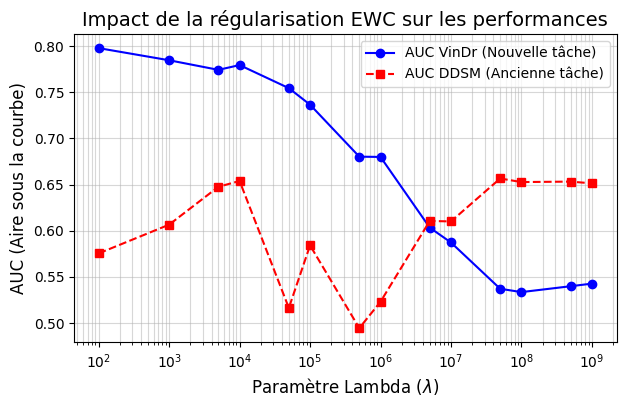

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))

# Tracé des courbes
plt.plot(lambda_liste, auc_vindr, marker='o', linestyle='-', color='blue', label='AUC VinDr (Nouvelle tâche)')
plt.plot(lambda_liste, auc_ddsm, marker='s', linestyle='--', color='red', label='AUC DDSM (Ancienne tâche)')

# Passage de l'axe X en échelle logarithmique pour mieux voir les petits lambdas
plt.xscale('log')

# Cosmétique du graphique
plt.title("Impact de la régularisation EWC sur les performances", fontsize=14)
plt.xlabel("Paramètre Lambda ($\lambda$)", fontsize=12)
plt.ylabel("AUC (Aire sous la courbe)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

# Ajout d'une ligne horizontale pour le score de référence sans EWC (optionnel)
# plt.axhline(y=0.85, color='gray', linestyle=':', label='Baseline DDSM')

plt.show()